<a href="https://colab.research.google.com/github/vasilyryabtsev/futures-price-prediction/blob/vasily/twitter/ML_methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [115]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, roc_curve, auc, precision_score
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import MaxAbsScaler, FunctionTransformer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from transformers import BertTokenizer, BertForSequenceClassification, pipeline, AutoTokenizer, AutoModelForSequenceClassification
from gensim.models import Word2Vec

RANDOM_STATE = 42

In [80]:
df = pd.read_csv('https://github.com/vasilyryabtsev/futures-price-prediction/blob/vasily/twitter/tweets.csv?raw=true').drop('Unnamed: 0', axis=1)
df

,text,is_quote_status,view_count,has_card,urls,day,month,year,is_in_reply_to,is_view_count,1_day_after
0,The chance of $MSFT winning an appeal of the ...,0,113387.0,0,0,26,4,2023,0,1,1
1,We love and appreciate all the volunteers at t...,0,707.0,0,0,6,5,2024,0,1,1
2,Today walking the lab on the NJ beach - tomorr...,0,702.0,0,0,8,5,2024,0,1,1
3,Today walking the lab on the NJ beach - tomorr...,0,702.0,0,0,8,5,2024,0,1,0
4,Good Morning from a dog walk on the $NVDA resc...,0,934.0,0,0,5,5,2024,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...
522,Autonomy takes center stage in this quarter's ...,0,6220.0,1,0,25,10,2024,0,1,1
523,Had to eat McDonalds over Wendy's this morning...,0,18324.0,0,0,23,9,2024,0,1,1
524,$BA big equity raise,0,1021.0,0,0,28,10,2024,0,1,0
525,$JPM gives the BTC miners 9 months to get a de...,0,1071.0,1,1,24,10,2024,0,1,1


In [81]:
df.shape

(527, 11)

In [82]:
Xtrain, Xtest, ytrain, ytest = train_test_split(df['text'], df['1_day_after'], test_size=0.1, random_state=RANDOM_STATE)

# Текстовые признаки

In [85]:
curves = {}

def add_curve(model, name):
    fpr, tpr, thresholds = roc_curve(ytest, model.predict_proba(Xtest)[:, 1])
    roc_auc = auc(fpr, tpr)

    curves[name] = {'fpr': fpr,
                        'tpr': tpr,
                        'thresholds': thresholds,
                        'roc_auc': roc_auc}

def print_metrics(model):
    print(f'ROC-AUC train: {roc_auc_score(ytrain, model.predict_proba(Xtrain)[:, 1])}')
    print(f'ROC-AUC test: {roc_auc_score(ytest, model.predict_proba(Xtest)[:, 1])}')
    print('Classification report for test:')
    print(classification_report(ytest, model.predict(Xtest)))

## Bag Of Words

In [86]:
pl = Pipeline([
    ("vectorizer", CountVectorizer()),
    ("classifier", LogisticRegression(max_iter=500, random_state=42))
])

pl.fit(Xtrain, ytrain)

pl.named_steps['vectorizer'].get_feature_names_out().shape

(3294,)

In [87]:
param_grid = {
    "vectorizer__max_features": [50, 150, 500, 1000, None],
    "vectorizer__ngram_range": [(1, 1), (1, 2)],
    "classifier__C": [0.1, 1, 10]
}

gs = GridSearchCV(pl, param_grid, cv=5, scoring="roc_auc", verbose=2, n_jobs=-1)

gs.fit(Xtrain, ytrain)

gs.best_estimator_, gs.best_score_

Fitting 5 folds for each of 30 candidates, totalling 150 fits


(Pipeline(steps=[('vectorizer', CountVectorizer()),
                 ('classifier',
                  LogisticRegression(C=1, max_iter=500, random_state=42))]),
 0.6140925170068027)

In [88]:
bow_lr = gs.best_estimator_

add_curve(bow_lr, 'bow_lr')

print_metrics(bow_lr)

ROC-AUC train: 0.9900758589915216
ROC-AUC test: 0.6041055718475073
Classification report for test:
              precision    recall  f1-score   support

           0       0.55      0.55      0.55        22
           1       0.68      0.68      0.68        31

    accuracy                           0.62        53
   macro avg       0.61      0.61      0.61        53
weighted avg       0.62      0.62      0.62        53



In [93]:
score = cross_val_score(bow_lr, Xtrain, ytrain, scoring='roc_auc', cv=5, n_jobs=-1)
print(score, np.var(score, ddof=1))

[0.602      0.70822222 0.51733333 0.65311111 0.58979592] 0.005120436346995336


## Tf-idf

In [95]:
pl = Pipeline([
    ("vectorizer", TfidfVectorizer()),
    ("classifier", LogisticRegression(max_iter=500, random_state=42))
])

pl.fit(Xtrain, ytrain)

pl.named_steps['vectorizer'].get_feature_names_out().shape

(3294,)

In [96]:
param_grid = {
    "vectorizer__max_features": [50, 150, 500, 1000, None],
    "vectorizer__ngram_range": [(1, 1), (1, 2)],
    "vectorizer__use_idf": [True, False],
    "vectorizer__smooth_idf": [True, False],
    "classifier__C": [0.1, 1, 10],
}

gs = GridSearchCV(pl, param_grid, cv=5, scoring="roc_auc", verbose=2, n_jobs=-1)

gs.fit(Xtrain, ytrain)

gs.best_estimator_, gs.best_score_

Fitting 5 folds for each of 120 candidates, totalling 600 fits


(Pipeline(steps=[('vectorizer',
                  TfidfVectorizer(ngram_range=(1, 2), smooth_idf=False)),
                 ('classifier',
                  LogisticRegression(C=0.1, max_iter=500, random_state=42))]),
 0.6333850340136055)

In [97]:
tfidf_lr = gs.best_estimator_

add_curve(tfidf_lr, 'tfidf_lr')

print_metrics(tfidf_lr)

ROC-AUC train: 0.9630343596608657
ROC-AUC test: 0.6099706744868035
Classification report for test:
              precision    recall  f1-score   support

           0       1.00      0.14      0.24        22
           1       0.62      1.00      0.77        31

    accuracy                           0.64        53
   macro avg       0.81      0.57      0.50        53
weighted avg       0.78      0.64      0.55        53



In [99]:
score = cross_val_score(tfidf_lr, Xtrain, ytrain, scoring='roc_auc', cv=5, n_jobs=-1)
print(score, np.var(score, ddof=1))

[0.62377778 0.67622222 0.57733333 0.65444444 0.63514739] 0.0013789304723854801


## [finbert-tone](https://huggingface.co/yiyanghkust/finbert-tone?text=growth+is+strong+and+we+have+plenty+of+liquidity)

### Прогноз "из коробки"

In [116]:
finbert = BertForSequenceClassification.from_pretrained('yiyanghkust/finbert-tone',num_labels=3)
tokenizer = BertTokenizer.from_pretrained('yiyanghkust/finbert-tone')
nlp = pipeline("sentiment-analysis", model=finbert, tokenizer=tokenizer)

Device set to use cpu


In [117]:
pos_neg_ans = list(filter(lambda x: x[0] != 'Neutral',
                     zip([res['label'] for res in nlp(df['text'].tolist())], df['1_day_after'])))

len(pos_neg_ans) / df['1_day_after'].shape[0] * 100

24.857685009487664

In [118]:
pred_true_ans = list(map(lambda x: (int(x[0] == 'Positive'), x[1]), pos_neg_ans))

print(classification_report([i[1] for i in pred_true_ans], [i[0] for i in pred_true_ans]))

              precision    recall  f1-score   support

           0       0.56      0.39      0.46        64
           1       0.55      0.70      0.61        67

    accuracy                           0.55       131
   macro avg       0.55      0.55      0.54       131
weighted avg       0.55      0.55      0.54       131



## [finbert ProcusAI](https://huggingface.co/ProsusAI/finbert)

In [100]:
nlp = pipeline("text-classification", model="ProsusAI/finbert")

Device set to use cpu


### Прогноз "из коробки"

In [ ]:
pos_neg_ans = list(filter(lambda x: x[0] != 'neutral',
                     zip([res['label'] for res in nlp(df['text'].tolist())], df['1_day_after'])))

len(pos_neg_ans) / df['1_day_after'].shape[0] * 100

Device set to use cpu


In [ ]:
pred_true_ans = list(map(lambda x: (int(x[0] == 'positive'), x[1]), pos_neg_ans))

print(classification_report([i[1] for i in pred_true_ans], [i[0] for i in pred_true_ans]))

              precision    recall  f1-score   support

           0       0.62      0.62      0.62        82
           1       0.59      0.59      0.59        75

    accuracy                           0.61       157
   macro avg       0.60      0.60      0.60       157
weighted avg       0.61      0.61      0.61       157



### Векторизация + логистическая регрессия

In [101]:
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")

# Токенезация
tokenized = df['text'].apply((lambda x: tokenizer.encode(x, add_special_tokens=True)))

# Паддинг (чтобы все тексты были одинаковой длины)
max_len = 0
for i in tokenized.values:
    if len(i) > max_len:
        max_len = len(i)
padded = np.array([i + [0]*(max_len-len(i)) for i in tokenized.values])

# Masking (нужно показать модели, что все нули это пустое место)
attention_mask = np.where(padded != 0, 1, 0)
input_ids = torch.tensor(padded)
attention_mask = torch.tensor(attention_mask)

# Применение модели
with torch.no_grad():
    last_hidden_states = model(input_ids, attention_mask=attention_mask)

features = last_hidden_states[0].numpy()

features_df = pd.DataFrame(features)

df_new = pd.concat([features_df, df.drop('text', axis=1)], axis=1)

In [102]:
Xtrain, Xtest, ytrain, ytest = train_test_split(df_new.drop('1_day_after', axis=1)[[0, 1, 2]],
                                                df['1_day_after'],
                                                test_size=0.1,
                                                random_state=RANDOM_STATE)

In [103]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],          # Регуляризация
    "penalty": ["l2", "l1", "elasticnet"], # Тип регуляризации
    "solver": ["lbfgs", "liblinear", "saga"], # Решатели
    "max_iter": [100, 500, 1000]           # Количество итераций
}

gs = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring="roc_auc", verbose=2, n_jobs=-1)

gs.fit(Xtrain, ytrain)

gs.best_estimator_, gs.best_score_

Fitting 5 folds for each of 135 candidates, totalling 675 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
300 fits failed out of a total of 675.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
75 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "/

(LogisticRegression(C=100, penalty='l1', solver='liblinear'),
 0.5701650793650794)

In [104]:
prosus_lr = gs.best_estimator_

add_curve(prosus_lr, 'prosus_lr')

print_metrics(prosus_lr)

ROC-AUC train: 0.5718518518518519
ROC-AUC test: 0.624633431085044
Classification report for test:
              precision    recall  f1-score   support

           0       0.53      0.45      0.49        22
           1       0.65      0.71      0.68        31

    accuracy                           0.60        53
   macro avg       0.59      0.58      0.58        53
weighted avg       0.60      0.60      0.60        53



In [105]:
score = cross_val_score(prosus_lr, Xtrain, ytrain, scoring='roc_auc', cv=5, n_jobs=-1)
print(score, np.var(score, ddof=1))

[0.658      0.55444444 0.51111111 0.60822222 0.51904762] 0.0038777059208868698


## Word2vec

In [106]:
sent = [row.split() for row in df['text']]

HIDDEN = 100 # каждое слово закодированно числовым вектором длины 100

model = Word2Vec(min_count=20,
                     window=2,
                     vector_size=HIDDEN,
                     sample=6e-5,
                     alpha=0.03,
                     min_alpha=0.0007,
                     negative=20,
                     workers=2)
model.build_vocab(sent, progress_per=10000) # собираем словарь слов
model.train(sent, total_examples=model.corpus_count, epochs=30, report_delay=1)

def get_mean_w2v_vector(sentence):
    Sum = 0
    Count = 0

    try:
      words = sentence.split()
    except TypeError:
      words = []

    for w in words:
        if w in model.wv:
            Sum += model.wv[w]
            # Sum += glove_vectors[w]
            Count += 1

    if Count == 0:
        return 0

    return Sum / Count

NewCols = ['col'+str(i) for i in range(HIDDEN)]

Xtrain, Xtest, ytrain, ytest = train_test_split(df['text'].to_frame(), df['1_day_after'], test_size=0.1, random_state=RANDOM_STATE)

Xtrain['vectors'] = Xtrain.map(get_mean_w2v_vector)
Xtest['vectors'] = Xtest.map(get_mean_w2v_vector)

IdxTrain = []

for ix, row in Xtrain.iterrows():
    if not isinstance(row['vectors'],np.ndarray):
        IdxTrain.append(ix)

IdxTest = []

for ix, row in Xtest.iterrows():
    if not isinstance(row['vectors'],np.ndarray):
        IdxTest.append(ix)

Xtrain.drop(index=IdxTrain, inplace=True)
Xtest.drop(index=IdxTest, inplace=True)

ytrain = ytrain.drop(index=IdxTrain)
ytest = ytest.drop(index=IdxTest)

Xtrain[NewCols] = pd.DataFrame(Xtrain['vectors'].tolist(), index=Xtrain.index)
Xtest[NewCols] = pd.DataFrame(Xtest['vectors'].tolist(), index=Xtest.index)
Xtrain.drop(['text','vectors'], axis=1, inplace=True)
Xtest.drop(['text','vectors'], axis=1, inplace=True)

<ipython-input-106-f40fb2be7336>:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Xtrain[NewCols] = pd.DataFrame(Xtrain['vectors'].tolist(), index=Xtrain.index)
<ipython-input-106-f40fb2be7336>:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Xtrain[NewCols] = pd.DataFrame(Xtrain['vectors'].tolist(), index=Xtrain.index)
<ipython-input-106-f40fb2be7336>:62: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all colum

In [108]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],          # Регуляризация
    "penalty": ["l2", "l1", "elasticnet"], # Тип регуляризации
    "solver": ["lbfgs", "liblinear", "saga"], # Решатели
    "max_iter": [100, 500, 1000]           # Количество итераций
}

gs = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring="roc_auc", verbose=2, n_jobs=-1)

gs.fit(Xtrain, ytrain)

gs.best_estimator_, gs.best_score_

Fitting 5 folds for each of 135 candidates, totalling 675 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
300 fits failed out of a total of 675.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
75 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "/

(LogisticRegression(C=100, max_iter=1000, solver='saga'), 0.5218604411461555)

In [109]:
w2v_lr = gs.best_estimator_

add_curve(w2v_lr, 'w2v_lr')

print_metrics(w2v_lr)

ROC-AUC train: 0.6576570729174394
ROC-AUC test: 0.6085043988269795
Classification report for test:
              precision    recall  f1-score   support

           0       0.70      0.32      0.44        22
           1       0.65      0.90      0.76        31

    accuracy                           0.66        53
   macro avg       0.68      0.61      0.60        53
weighted avg       0.67      0.66      0.62        53



In [110]:
score = cross_val_score(w2v_lr, Xtrain, ytrain, scoring='roc_auc', cv=5, n_jobs=-1)
print(score, np.var(score, ddof=1))

[0.43900742 0.62523191 0.44990724 0.50858071 0.58611111] 0.006758001108247375


## Roc кривые

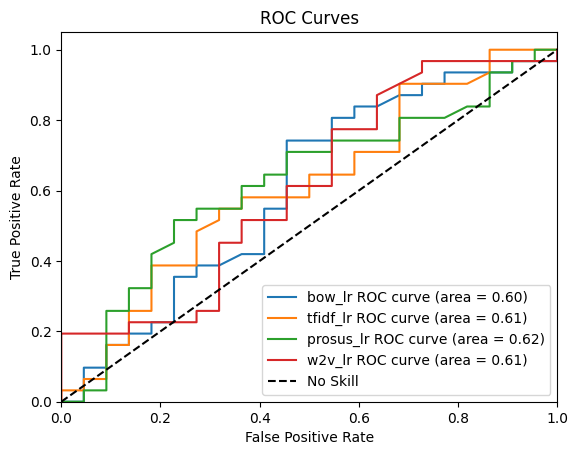

In [113]:
plt.figure()

for model in curves:
    curve = curves[model]
    plt.plot(curve['fpr'], curve['tpr'], label=f"{model} ROC curve (area = {curve['roc_auc']:0.2f})")
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

# Все признаки

In [114]:
df

,text,is_quote_status,view_count,has_card,urls,day,month,year,is_in_reply_to,is_view_count,1_day_after
0,The chance of $MSFT winning an appeal of the ...,0,113387.0,0,0,26,4,2023,0,1,1
1,We love and appreciate all the volunteers at t...,0,707.0,0,0,6,5,2024,0,1,1
2,Today walking the lab on the NJ beach - tomorr...,0,702.0,0,0,8,5,2024,0,1,1
3,Today walking the lab on the NJ beach - tomorr...,0,702.0,0,0,8,5,2024,0,1,0
4,Good Morning from a dog walk on the $NVDA resc...,0,934.0,0,0,5,5,2024,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...
522,Autonomy takes center stage in this quarter's ...,0,6220.0,1,0,25,10,2024,0,1,1
523,Had to eat McDonalds over Wendy's this morning...,0,18324.0,0,0,23,9,2024,0,1,1
524,$BA big equity raise,0,1021.0,0,0,28,10,2024,0,1,0
525,$JPM gives the BTC miners 9 months to get a de...,0,1071.0,1,1,24,10,2024,0,1,1


# Выводы

Наилучший результат показала логистическая регрессия, обученная на текстах, векторизованных с помощью предобученной finbert (ProcusAI), и на вещественных признаках. Так же для данной модели был осуществлен подбор оптимального гиперпараметра: C=1.77.

accuracy (train, test): 0.611, 0.679

roc-auc (train, test): 0.605, 0.653

По значению метрик видно, что модель скорее всего немного недообучилась. Это связано с маленьким размером датасета.

# Что можно улучшить?

1. Собрать больше данных
2. Попробовать SVM на разных ядрах